In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("Notebook: Non-IID Analysis")
print("Goal: Show visually that 4 factories have different data distributions")
print("This is WHY federated learning with clustering is needed")

Notebook: Non-IID Analysis
Goal: Show visually that 4 factories have different data distributions
This is WHY federated learning with clustering is needed


## Load all 4 datasets

In [2]:
def load_dataset(filename):
    col_names = (
        ['engine_id', 'cycle'] +
        ['setting_1', 'setting_2', 'setting_3'] +
        ['sensor_' + str(i) for i in range(1, 22)]
    )
    df = pd.read_csv(filename, sep='\s+', header=None)
    df.columns = col_names
    df['factory'] = filename.replace('train_', '').replace('.txt', '')
    return df

fd001 = load_dataset('train_FD001.txt')
fd002 = load_dataset('train_FD002.txt')
fd003 = load_dataset('train_FD003.txt')
fd004 = load_dataset('train_FD004.txt')

print("Loaded all 4 datasets")
print(f"FD001: {len(fd001):>6} rows, {fd001['engine_id'].nunique()} engines")
print(f"FD002: {len(fd002):>6} rows, {fd002['engine_id'].nunique()} engines")
print(f"FD003: {len(fd003):>6} rows, {fd003['engine_id'].nunique()} engines")
print(f"FD004: {len(fd004):>6} rows, {fd004['engine_id'].nunique()} engines")

Loaded all 4 datasets
FD001:  20631 rows, 100 engines
FD002:  53759 rows, 260 engines
FD003:  24720 rows, 100 engines
FD004:  61249 rows, 249 engines


## Show operating settings are different

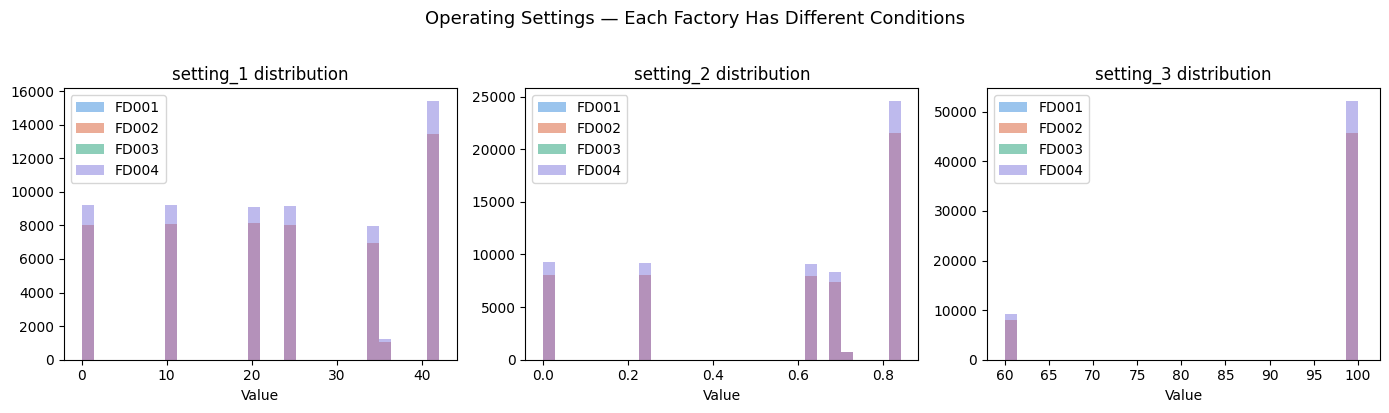

FD001 unique setting_1 values: 158
FD002 unique setting_1 values: 536

FD001 has 1 operating condition — setting_1 is almost constant
FD002 has 6 operating conditions — setting_1 jumps between 6 values
This is the Non-IID difference between factories


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = {'FD001': fd001, 'FD002': fd002, 
            'FD003': fd003, 'FD004': fd004}
colors = {'FD001': '#378ADD', 'FD002': '#D85A30',
          'FD003': '#1D9E75', 'FD004': '#7F77DD'}

for i, setting in enumerate(['setting_1', 'setting_2', 'setting_3']):
    for name, df in datasets.items():
        axes[i].hist(df[setting], bins=30, alpha=0.5,
                     label=name, color=colors[name])
    axes[i].set_title(f'{setting} distribution')
    axes[i].set_xlabel('Value')
    axes[i].legend()

plt.suptitle('Operating Settings — Each Factory Has Different Conditions',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart_operating_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print("FD001 unique setting_1 values:", fd001['setting_1'].nunique())
print("FD002 unique setting_1 values:", fd002['setting_1'].nunique())
print()
print("FD001 has 1 operating condition — setting_1 is almost constant")
print("FD002 has 6 operating conditions — setting_1 jumps between 6 values")
print("This is the Non-IID difference between factories")

## Sensor distributions across factories

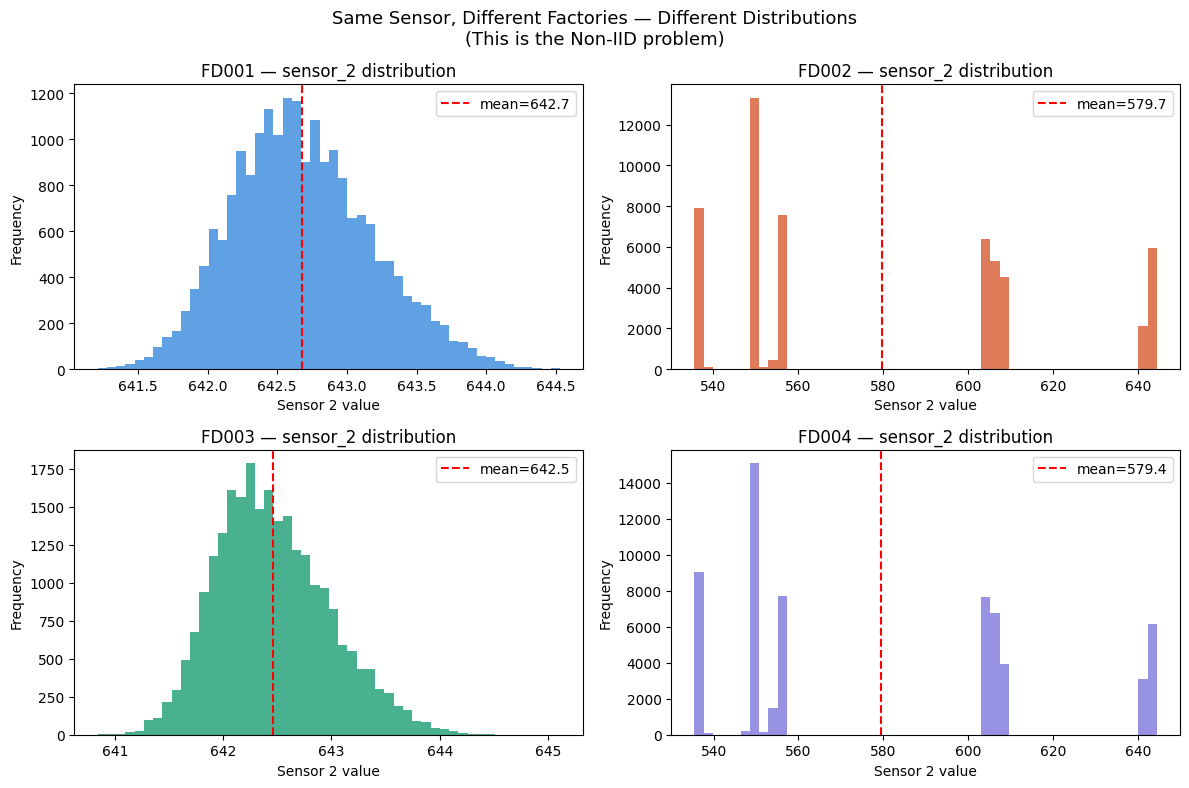

In [4]:
# Compare sensor_2 distribution across all 4 factories
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    axes[i].hist(df['sensor_2'], bins=50, 
                 color=colors[name], alpha=0.8)
    axes[i].set_title(f'{name} — sensor_2 distribution')
    axes[i].set_xlabel('Sensor 2 value')
    axes[i].set_ylabel('Frequency')
    
    mean = df['sensor_2'].mean()
    axes[i].axvline(x=mean, color='red', linestyle='--',
                    label=f'mean={mean:.1f}')
    axes[i].legend()

plt.suptitle('Same Sensor, Different Factories — Different Distributions\n(This is the Non-IID problem)',
             fontsize=13)
plt.tight_layout()
plt.savefig('chart_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Engine survival curves

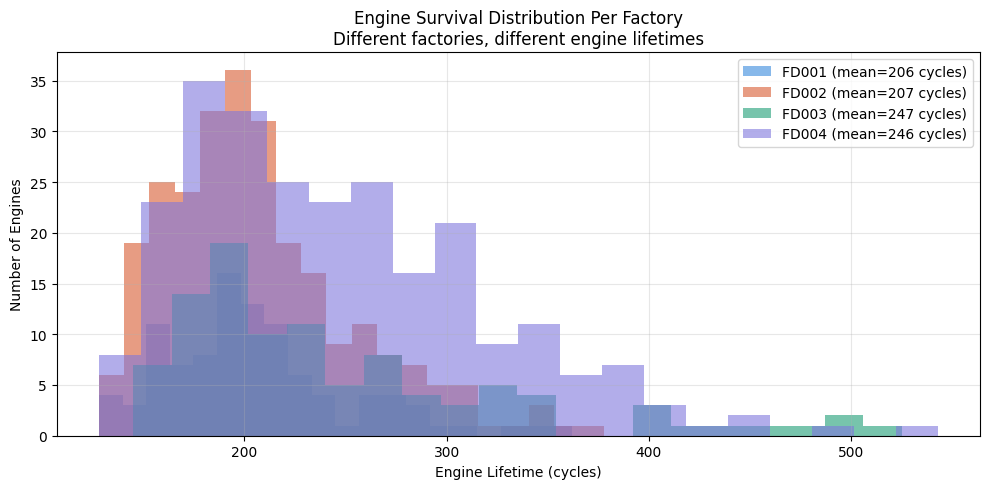

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, df in datasets.items():
    survival = df.groupby('engine_id')['cycle'].max()
    ax.hist(survival, bins=20, alpha=0.6,
            label=f'{name} (mean={survival.mean():.0f} cycles)',
            color=colors[name])

ax.set_xlabel('Engine Lifetime (cycles)')
ax.set_ylabel('Number of Engines')
ax.set_title('Engine Survival Distribution Per Factory\nDifferent factories, different engine lifetimes')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## The conclusion

In [6]:
print("=" * 60)
print("NON-IID ANALYSIS CONCLUSION")
print("=" * 60)
print()
print("1. OPERATING CONDITIONS:")
print("   FD001, FD003 → 1 operating condition (simple, consistent)")
print("   FD002, FD004 → 6 operating conditions (complex, varied)")
print()
print("2. SENSOR DISTRIBUTIONS:")
print("   Each factory has different sensor value ranges")
print("   A model trained on FD001 data will NOT generalise to FD002")
print()
print("3. ENGINE LIFETIMES:")
print("   Different factories have different average engine lifetimes")
print("   FD002/FD004 engines are generally harder to predict")
print()
print("4. WHAT THIS MEANS FOR FEDERATED LEARNING:")
print("   A single global model (FedAvg without clustering) will be")
print("   pulled in different directions by each factory's gradients")
print("   → mediocre performance for everyone")
print()
print("   With adaptive clustering:")
print("   → FD001 + FD003 form Cluster A (simple factories)")
print("   → FD002 + FD004 form Cluster B (complex factories)")
print("   → Each cluster gets a model tuned to its conditions")
print("   → Better accuracy for everyone")
print()
print("This notebook proves the Non-IID problem exists in our data.")
print("The FL system proves clustering solves it.")

NON-IID ANALYSIS CONCLUSION

1. OPERATING CONDITIONS:
   FD001, FD003 → 1 operating condition (simple, consistent)
   FD002, FD004 → 6 operating conditions (complex, varied)

2. SENSOR DISTRIBUTIONS:
   Each factory has different sensor value ranges
   A model trained on FD001 data will NOT generalise to FD002

3. ENGINE LIFETIMES:
   Different factories have different average engine lifetimes
   FD002/FD004 engines are generally harder to predict

4. WHAT THIS MEANS FOR FEDERATED LEARNING:
   A single global model (FedAvg without clustering) will be
   pulled in different directions by each factory's gradients
   → mediocre performance for everyone

   With adaptive clustering:
   → FD001 + FD003 form Cluster A (simple factories)
   → FD002 + FD004 form Cluster B (complex factories)
   → Each cluster gets a model tuned to its conditions
   → Better accuracy for everyone

This notebook proves the Non-IID problem exists in our data.
The FL system proves clustering solves it.
